For the analysis of the data, let's start asking some questions
One that could give us a good example would be 

"where does the majority of car incidents occur?"

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
complete_dataset = pd.read_csv('data/complete_dataset.csv')
complete_dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 113850 entries, 0 to 113849
Data columns (total 10 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Unnamed: 0          113850 non-null  int64  
 1   Comune              113835 non-null  str    
 2   REF_AREA            113850 non-null  int64  
 3   DATA_TYPE           113850 non-null  str    
 4   RESULT              113850 non-null  str    
 5   OBS_VALUE           113850 non-null  int64  
 6   Codice Comune       113850 non-null  int64  
 7   Anno                113850 non-null  int64  
 8   Popolazione legale  113850 non-null  int64  
 9   Area                113850 non-null  float64
dtypes: float64(1), int64(6), str(3)
memory usage: 8.7 MB


In [3]:
cities_with_most_incidents = complete_dataset[complete_dataset['DATA_TYPE']=='ROADACC']
cities_with_most_incidents.info()

<class 'pandas.DataFrame'>
Index: 37950 entries, 10 to 113849
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Unnamed: 0          37950 non-null  int64  
 1   Comune              37945 non-null  str    
 2   REF_AREA            37950 non-null  int64  
 3   DATA_TYPE           37950 non-null  str    
 4   RESULT              37950 non-null  str    
 5   OBS_VALUE           37950 non-null  int64  
 6   Codice Comune       37950 non-null  int64  
 7   Anno                37950 non-null  int64  
 8   Popolazione legale  37950 non-null  int64  
 9   Area                37950 non-null  float64
dtypes: float64(1), int64(6), str(3)
memory usage: 3.2 MB


In [5]:
cities_with_most_incidents_2020 = cities_with_most_incidents[cities_with_most_incidents['Anno']==2020]
cities_with_most_incidents_2020['OBS_VALUE'].describe()

count    7903.000000
mean       14.968746
std       126.533729
min         0.000000
25%         1.000000
50%         2.000000
75%         8.000000
max      8229.000000
Name: OBS_VALUE, dtype: float64

Text(0, 0.5, 'Incidenti')

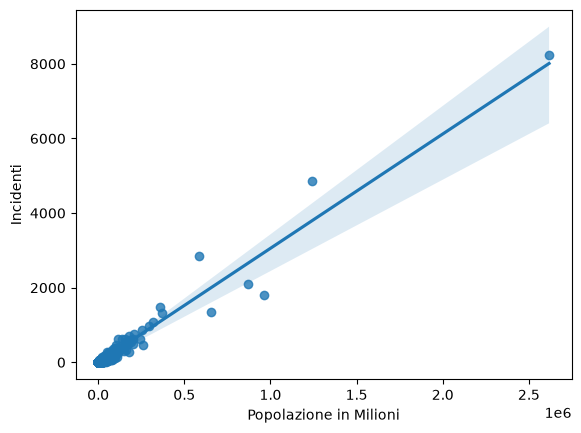

In [6]:
sns.regplot(data=cities_with_most_incidents_2020, x='Popolazione legale', y='OBS_VALUE', label='Incidenti')
plt.xlabel('Popolazione in Milioni')
plt.ylabel('Incidenti')

With this we have a general idea of what is happening, through all of the italian cities, only 8 are considered outliers, meaning that they have the highest number of car accident registered in the 2020 and the italian average is way lower, around 15.

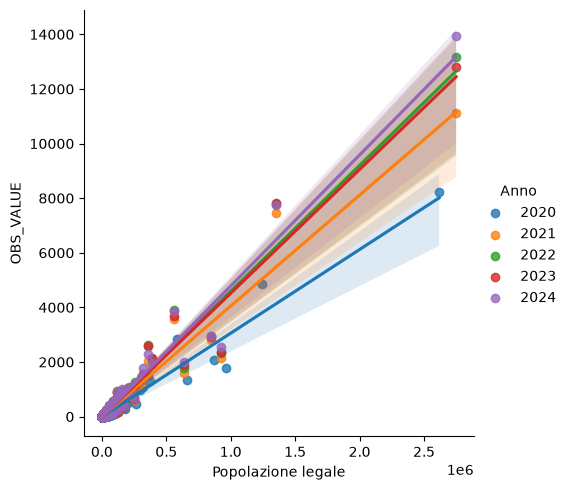

In [ ]:
sns.lmplot(data=cities_with_most_incidents, x='Popolazione legale', y='OBS_VALUE', hue='Anno')

with this graph we compare each city with it's next years and we can observe that each city kept their number of incidents more or less the same, ad exception of one, let's isolate it and find out who that is

In [16]:
cities_with_most_incidents.sort_values(by=['Popolazione legale'], ascending=False).head(5)

,Unnamed: 0,Comune,REF_AREA,DATA_TYPE,RESULT,OBS_VALUE,Codice Comune,Anno,Popolazione legale,Area
68414,68414,Roma,58091,ROADACC,9,11129,58091,2021,2749031,1288.1875
68415,68415,Roma,58091,ROADACC,9,13181,58091,2022,2749031,1288.1875
68416,68416,Roma,58091,ROADACC,9,12817,58091,2023,2749031,1288.1875
68417,68417,Roma,58091,ROADACC,9,13924,58091,2024,2749031,1288.1875
68413,68413,Roma,58091,ROADACC,9,8229,58091,2020,2617175,1287.3716


the most dangerous city is considered Rome because it's the only city what registered a major increase in the number of car incident

In [26]:
top_10_cities_with_most_incidents = cities_with_most_incidents.sort_values(by=['OBS_VALUE'], ascending=False).head(45)
top_10_cities_with_most_incidents['Comune'].unique()

<StringArray>
[   'Roma',  'Milano',  'Genova',  'Torino', 'Firenze',  'Napoli', 'Bologna',
 'Palermo',    'Bari', 'Catania']
Length: 10, dtype: str

NUMBER OF FATAL CRASHES

In [ ]:
cities_with_most_injuries = complete_dataset[complete_dataset['DATA_TYPE']=='KILLINJ']
cities_with_most_injuries.info()

#let's split the database into 2 groups, injured (F) and dead (M)

injuries_from_crashes = cities_with_most_injuries[cities_with_most_injuries['RESULT']=='F']
death_from_crashes = cities_with_most_injuries[cities_with_most_injuries['RESULT']=='M']

<class 'pandas.DataFrame'>
Index: 75900 entries, 0 to 113844
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Unnamed: 0          75900 non-null  int64  
 1   Comune              75890 non-null  str    
 2   REF_AREA            75900 non-null  int64  
 3   DATA_TYPE           75900 non-null  str    
 4   RESULT              75900 non-null  str    
 5   OBS_VALUE           75900 non-null  int64  
 6   Codice Comune       75900 non-null  int64  
 7   Anno                75900 non-null  int64  
 8   Popolazione legale  75900 non-null  int64  
 9   Area                75900 non-null  float64
dtypes: float64(1), int64(6), str(3)
memory usage: 6.4 MB


np.int64(17196)

Text(0, 0.5, 'Feriti')

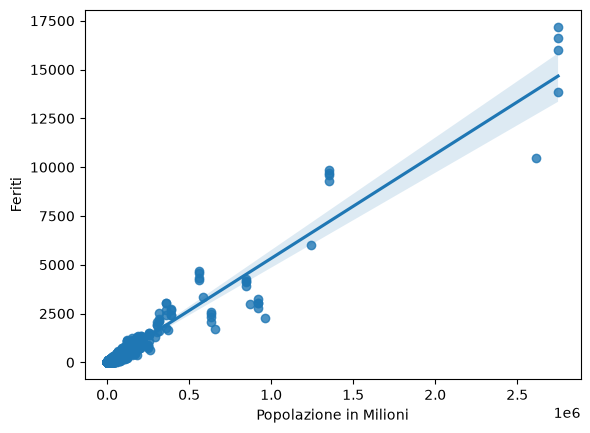

In [34]:
sns.regplot(data=injuries_from_crashes, x='Popolazione legale', y='OBS_VALUE', label='Feriti')
plt.xlabel('Popolazione in Milioni')
plt.ylabel('Feriti')

Text(0, 0.5, 'Feriti')

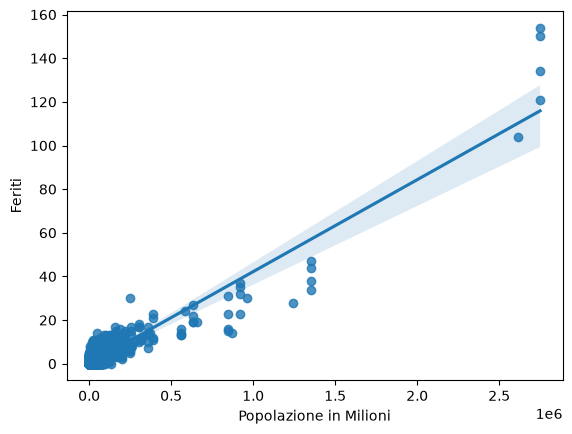

In [35]:
sns.regplot(data=death_from_crashes, x='Popolazione legale', y='OBS_VALUE', label='Feriti')
plt.xlabel('Popolazione in Milioni')
plt.ylabel('Feriti')

This way we have a clearer idea of the mortality of those incidents and judging from the last 2 graphs the number of injuries is several times higher than the deaths